# Oxford Flowers102(Flawer Species Classification) using EfficientNet V2

### DataSet Description
A benchmark(use to compare the models) dataset containing __102__ flower categories, widely used for fine-grained(comapre b/w almost similar classes) image classification tasks.
__Dataset Details__:-

_Total Images_:- __8189__,
_Classes_:- __102__,
_Classification Type_:- __Multi-Class Classification__,
_Color Channels_:- __RGB__,
_Original Image Resolution_:- __Variable__,
_Training Images_:-__1020__,
_Validation Images_:-__1020__,
_Test Images_:-__6149__

The dataset contains natural variations in:

* illumination
* background
* scale
* orientation
* flower position

### Why Oxford Flowers102
The Oxford Flowers102 dataset was selected because it is a standard benchmark dataset for fine-grained image classification. Unlike general image classification datasets such as CIFAR-10, many flower species in this dataset have very similar visual characteristics, making the classification task significantly more challenging.

### Model Selection:- EfficientNetV2
This model provides the excepllent balance between accuracy, training speed, and computational efficiency. It's pretrained ImageNet weights enable transfer learning, improving performance while reducing training time.


### Importing Libraries

In [1]:
# 1. Importing Libraries
import torch  # PyTorch is main DL library. We will use it for tensors, GPU computations, Neural Networks, Loss functions, optimizers.
import random # for random seed(reporducability)
import numpy as np # Numerical operations, image arrays, metrics
import matplotlib.pyplot as plt # For visulaizing images
from torch.utils.data import DataLoader # DataLoader:- Loads data from dataset, creates batches,Shuffles the data, Sends a batch at a time to the model, Uses parallel computing to load multiple images and utilize GPU cores, Return tensors ex:-(32,3,224,224) instead of PIL(object created with Python Image Library) image
from torch.utils.data import random_split
from torchvision.datasets import Flowers102 #(Torchvision contains image datasets, image transformers, pretrained cnn models, image utilities)

# Importing the model
from torchvision.models import(
efficientnet_v2_s,             # Pretrained model as the use of transfer learning
EfficientNet_V2_S_Weights     #PreTrained weights

)

from torchvision import transforms  # transforms are used to preprocess the images before they fed to the neural network

import torch.optim as optim # contains different optimization algorithm that updates the weights
print("Imports are available!")

Imports are available!


### Loading Dataset

In [2]:
#  The whole data is stored in single location wheir we specified first train_dataset storage but their is a file named as setid.mad which holds the group of training, valdation and testing data and loads on the basis of split

train_dataset=Flowers102(  # Contains training images + training Labels
    root="/content/data",     # tells the location wheir to store the dataset, as when we need it again during another project, no need to download dataset again
    split="train",   # Loads training images
    download=True    # downloads the dataset if it is not already present in specified directory
)
val_dataset = Flowers102(
    root="/content/data",
    split="val",       # As Flower102 has already contains the validation dataset, so we use that one
    download=True
)
test_dataset = Flowers102(
    root="/content/data",
    split="test",
    download=True)


100%|██████████| 345M/345M [00:13<00:00, 25.3MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.80MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 37.8MB/s]


### Dataset Verification

In [3]:
# Verifying the dataset
print (type(train_dataset))
print(len(train_dataset))
print (len(val_dataset))
print (len(test_dataset))

<class 'torchvision.datasets.flowers102.Flowers102'>
1020
1020
6149


### Inspection a Sample

In [4]:
# Here, we inspect 1 image and it's corresponding label
image, label=train_dataset[0]
print (type(image))
print (type(label))
print (label)

for i in range(20):
    _, label = train_dataset[i] # Here we need label no need of image, that's why _, label
    print(f"Image {i}: Label = {label}")

# Checking the Image size
print (image.size)  # Returns the height and width of image

# Need to prove image size is variable, so we check it with different images
for i in range(10):
    image, _ = train_dataset[i] # Here we need only image no need of label, that's why image, _
    print(f"Image {i}: {image.size}")

<class 'PIL.Image.Image'>
<class 'int'>
0
Image 0: Label = 0
Image 1: Label = 0
Image 2: Label = 0
Image 3: Label = 0
Image 4: Label = 0
Image 5: Label = 0
Image 6: Label = 0
Image 7: Label = 0
Image 8: Label = 0
Image 9: Label = 0
Image 10: Label = 1
Image 11: Label = 1
Image 12: Label = 1
Image 13: Label = 1
Image 14: Label = 1
Image 15: Label = 1
Image 16: Label = 1
Image 17: Label = 1
Image 18: Label = 1
Image 19: Label = 1
(754, 500)
Image 0: (754, 500)
Image 1: (624, 500)
Image 2: (667, 500)
Image 3: (750, 500)
Image 4: (500, 714)
Image 5: (667, 500)
Image 6: (750, 500)
Image 7: (667, 500)
Image 8: (500, 654)
Image 9: (578, 500)


The first sample from the training dataset is inspected. The image is returned as a PIL Image, while the corresponding label is an integer representing the flower class. The labels of the first 20 samples are also checked to observe how the dataset is organized before shuffling. All images are grouped together according to their classes before shuffle. We need to use the __dataloader__ to shuffle them.

For checking, if the size is variable or not, we computed the size of first few images, and as we saw all have different height and width. So, the size is variable.

### Visualizing the image

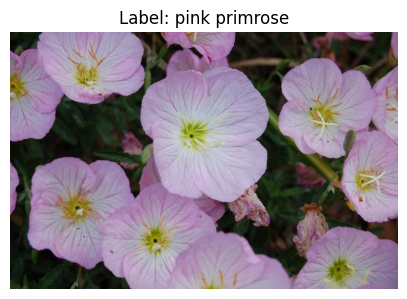

In [5]:
image, label=train_dataset[0]
plt.figure(figsize=(5,5)) # Creating the canvas for plotting the figure
plt.imshow(image)  # Displays the PIL image
plt.title(
    f"Label: {train_dataset.classes[label]}"
)
plt.axis("off") # Removing the axis, as without this we see the actual pixels of the image
plt.show()

### Loading pretrained weights

In [6]:
weights = EfficientNet_V2_S_Weights.DEFAULT
print (weights)

EfficientNet_V2_S_Weights.IMAGENET1K_V1


The default ImageNet-1K pretrained weights are loaded for EfficientNetV2-S. These weights also provide the recommended preprocessing transforms that will be used later to prepare the input images.

ImageNet-1K is a benchmark image dataset containing approximately 1.28 million RGB images across 1000 object categories. EfficientNetV2-S is pretrained on this dataset, allowing us to use transfer learning by reusing the learned visual features for our flower classification task.

### Inspecting the Recommended Preprocessing Pipeline

In [7]:
weights.transforms()

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

The weight is an object that stores 3 things-> model parameters(millions of learned weights), metadata(categories, accuracy, documentation..), recommened transform pipeline (Resize, crop, mean, std, interpolation) and the tranforms method reads these stored value by creating it's object and then it generates a preprocessing pipeline with these values.

__We are using ImageNet transforms on Flowers102__ because EfficientNetV2-S was trained on ImageNet-1K, it expects images to be preprocessed in the same way. Therefore, instead of creating our own preprocessing, we use weights.transforms() to prepare our dataset in the format expected by the pretrained model.

### Building the Transform Pipeline

train_transform → Used for the training dataset.

eval_transform → Used for validation and test datasets.

In [8]:
train_transform=weights.transforms()
eval_transform=weights.transforms()

The preprocessing returned by weights.transforms() is a deterministic preprocessing pipeline (resize, crop, tensor conversion, normalization). It does not include random augmentations like flips or rotations.

Preprocessing prepares every image in a consistent format for the model, so it is used for training, validation, and testing. Whereas, Data augmentation artificially creates variations of training images to improve generalization, so it is applied only to the training dataset and never to the validation or test datasets.

### Applying the Preprocessing Pipeline

In [9]:
train_dataset=Flowers102(
    root="/content/data",
    split="train",
    transform=train_transform,  # Whenever someone asks for an image, it first applies train_transform, then return it.
    download=False
)
val_dataset=Flowers102(
    root="/content/data",
    split="val",
    transform=eval_transform,
    download=False
)
test_dataset=Flowers102(
    root="/content/data",
    split="test",
    transform=eval_transform,
    download=False
)

The Flowers102 object doesn't let us change its transform after it's created. So we simply create a new dataset object with the transform attached. It converts the original PIL image into a tensor formatted for EfficientNetV2-S.

### Verifying the Preprocessed Image

In [10]:
image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(image.dtype)
print(label)
# print (image)  it returns the normalized pixel values

<class 'torch.Tensor'>
torch.Size([3, 384, 384])
torch.float32
0


<class 'torch.Tensor'> :-weights.transforms() converted the PIL image into a PyTorch tensor.

PyTorch stores images as (Channels, Height, Width) whereas in munpy it stored as (Height, Width, Channels). Here, 3 in output represents the RGB channel.

Earlier pixels values were integers between 0-255, but after preprocessing and normalization, they become floating-point values (float32), which neural networks use for computations.

### Creating DataLoaders

In [11]:
Batch_size=32 # It is taken as 4 because it balances memory usage, training speed, and learning stability.

train_loader=DataLoader(
    train_dataset,
    batch_size=Batch_size,
    shuffle=True  # to improve the learning we shuffle the training data, as previously the images of each classes are grouped together
)

val_loader=DataLoader(
    val_dataset,
    batch_size=Batch_size,
    shuffle=False # keeps the validation and test data original for better evaluation
)

test_loader=DataLoader(
    test_dataset,
    batch_size=Batch_size,
    shuffle=False
)

Instead of evaluating image 1 by 1, we give a batch to GPU and collect the response of the batch itself not a single image. This batch creation task is done by DataLoader and to improve the learning we shuffle the training data, about validation and test -> no need the order must be kept original for proper evaluation.

### Verifying the DataLoader

In [12]:
images, labels=next(iter(train_loader))   # as dataloader contains many batches so it is iterable and iter(train_loader) creates an iterator that points to the first batch. next returns the next first available batch for beginning it returns the first batch.
print (images.shape)
print (images.dtype)
print (labels.shape)
print (labels.dtype)
# print (images)

torch.Size([32, 3, 384, 384])
torch.float32
torch.Size([32])
torch.int64


The image tensor has the shape (Batch Size, Channels, Height, Width), while the label tensor contains one class label for each image in the batch.

iter(train_loader) creates an iterator that starts at the beginning of the DataLoader. The next() function returns the next available batch from that iterator. Since a newly created iterator starts from the first batch, next(iter(train_loader)) always returns the first batch.

### Visualizing a preprocessed image

Matplotlib works well with numpy arrays so we convert our image from PyTorch Tensor to numpy array

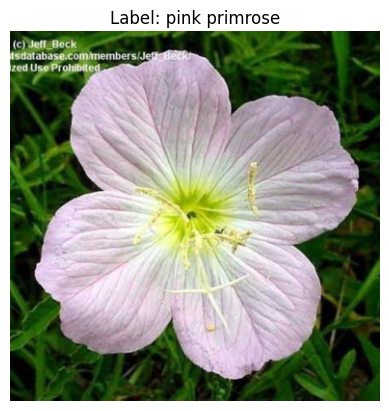

In [13]:
# images, labels = next(iter(train_loader))

# Convert to HWC:- Height, Width, Channel format
image = images[0].permute(1, 2, 0).numpy()  # permute change the order of the dimensions of the image as matplotlib only accepts HWC image and Pytorch have CHW format

mean = np.array([0.485, 0.456, 0.406])  # mean of all 3 chhanels extracted from ImageNet Data
std = np.array([0.229, 0.224, 0.225])   # std of ImageNet dataset, we are creating these because we have to de-normalize the images

# De-normalize
image = image * std + mean
image = np.clip(image, 0, 1)  # As matplotlib accepts +ve values ranges between 0 to 1 for images

plt.imshow(image)
# plt.title(f"Label: {labels[0].item()}")  # Labels[0] returns tensor (Class) to extract class --> .item()
plt.title(
    f"Label: {train_dataset.classes[label]}"
)
plt.axis("off")
plt.show()

We have done de-normalization because after the normalization the values comes as -ve as well as +ve but matplotlib accepts only +ve values ranges between 0 to 1 for floating point images

### Loading PreTrained Model

In [14]:
# Here Pytorch creates complete EfficientNetV2-S architecture, it loads pretrained imageNet weights into every layer
model=efficientnet_v2_s(weights=weights) # the model is now ready for transfer learning
# print (model)

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 128MB/s]


Final classifier found at model.classifier.

Last layer: Linear(1280 → 1000).

This layer will be replaced with Linear(1280 → 102) for the Flowers102 dataset.

# Feature Extraction

### Freezing the Backbone -> Feature Extraction Layers

We freeze the pretrained backbone to preserve the useful features learned from ImageNet, reduce training time, lower the risk of overfitting, and train only the new classification layer for the target dataset.

In [15]:
# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False  # To not compute gradient for this parameter and not to update the weight for pretrained weights
    # Backbone:-Feature extractor, classifier:- decision maker

### Preplacing the Classification Layer

In [16]:
import torch.nn as nn  # it contains all neural network layers

# Replacing the final Linear Layer
model.classifier[1]=nn.Linear(     # 1 because 0 is for drop out layer and 1 is for linear layer and we have to replace only the linear layer
    # This creates a new fully connected layer
    in_features=1280,   # in_Features remains same because the backbone layer gives 1280 features after training so next layer also receive the same no. of features
    out_features=102
)

### Configuring the device
The available computing device is detected automatically. If a CUDA-enabled GPU is available, the model is moved to the GPU for faster training; otherwise, the CPU is used.

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)  # moving the model to that device either it is CPU or it could be GPU(cuda)

print(device)

cuda


### Defining the loss function
As Oxford Flowers 102 is a multi-class classification problem with 102 classes, so we use the crossEntropy Loss function. It measures the difference between predicted and actual class labels, guiding us to improve its prediction during training.

In [18]:
loss_function=nn.CrossEntropyLoss()

### Defining the optimizer
It updates trainable model parameters based on the gradient to minimize the loss.Adam is used because it provides fast and stable convergence.

In [19]:
optimizer=optim.Adam(    # Update the trainiable weights so that loss decrease, Adam is better than Stochastic Gradient descent as it converges faster and automatically adjusts it's learning rate
    model.classifier.parameters(),    # As backbone is frozen, so only classifier weights needs to be update
    lr=0.001
)

# Training

### Traning the model with 1 epoch

In [20]:
def train_one_epoch(model, dataloader, loss_function, optimizer, device):   # Loss function-> crossEntropyLoss, optimizer:- updates model weight(Adam), device(CPU or GPU)
    model.train()   # with this the model is now in traning phase and dropout layer remain enabled and batch normalization occurs as updates running statistics

    running_loss=0.0  # Sum of losses from all batches
    correct=0   # Total correctly classified images
    total=0  # Total images processed

    for images, labels in dataloader:      # The dataLoader gives one batch at a time loop continues until all images haven't processed
        images=images.to(device)           # Moving the images and labels to same device of model to protect mismatch
        labels=labels.to(device)

        optimizer.zero_grad()              # Before processing a new batch, we clear the previous gradient
        outputs=model(images)              # Forward pass, it returns the predicted score predicts by the model

        loss=loss_function(outputs, labels)   # Calculating the loss between actual and predicted label with the help of cross_entropy_loss
        loss.backward()                       # It performs backpropagation as computing the gradient of the loss wrt to every trainable parameter
        torch.nn.utils.clip_grad_norm_(
        model.classifier.parameters(),
        max_norm=1.0
        )
        optimizer.step()                      # Now Adam uses those gradients to update the weight
        running_loss+=loss.item()             # After an epoch average loss is comuted and added to the running loss, loss is pytorch tensor so .item converts it into normal number

        _,predicted= torch.max(outputs, 1)      # it returns max value and max index of the predicted class with the given value, but we don't have any need of max value so we ignore that
        total+=labels.size(0)                   # it keeps track of total images processed
        correct+=(predicted==labels).sum().item()   # it counts total correct prediction
    epoch_loss=running_loss/len(dataloader)     # Average loss over all batches in one epoch
    epoch_acc=correct/total   # overall training accuracy for the epoch

    return epoch_loss, epoch_acc

### Evaluating the model
It measures the performance on the validation or test dataset without updating the model parameters. It computes the average loss and accuracy when the model is in evaluation mode.

In [21]:
def evaluate(model, dataloader, loss_function, device):  # evaluation on validation and test dataset
    model.eval()  # switches the model to evaluation mode--> dropout is disabled and batch normalization stops undating it's statistics

    running_loss=0.0
    correct=0
    total=0

    # print(len(dataloader.dataset))
    # print(len(dataloader))
    with torch.no_grad():              # <-- IMPORTANT
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss=running_loss/len(dataloader)
    epoch_acc=correct/total

    return epoch_loss, epoch_acc

### Training the model for multiple epochs
We use fit() function here, that trains the model for multiple epochs. After each epoch, it evaluates the model with validation dataset, records training and validation metrics, then save model with best validation accuracy.

In [22]:
def fit(model, train_loader, val_loader, loss_function, optimizer, device, epochs):
    train_losses=[]    # Stores training loss after every epoch
    train_accs=[]      # Stores training accuracy after every epoch

    val_losses=[]      # Validation loss
    val_accs=[]        # Validation accuracy

    best_acc=0        # Stores highest validation accuracy

    # epoch loop for training
    for epoch in range (epochs):
        # for each epoch:- train 1 epoch -> evaluate -> save best model -> store metrices -> printing the result
        train_loss, train_acc=train_one_epoch(model, train_loader, loss_function, optimizer, device)
        val_loss, val_acc=evaluate(model, val_loader, loss_function, device)

        #  Recording training and validation matrices
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if (val_acc>best_acc):
            best_acc=val_acc
            torch.save(model.state_dict(), "best_model.pth")  # saving the best model weight to a file , best_model.pth -> file that contains all learned parameters of best performing model

            # Printing the results
        print (
            f"Epoch [{epoch+1}/{epochs}]"
            f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f} | "f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}  "
            )
    return train_losses, train_accs, val_losses, val_accs

__state_dict__ -> returns dictionary contains all trainable parameters (weights and biases) of the model.

__torch.save__ -> saves all these parameters to a file, so best-performing parameteric model can be loaded later.

### Traning the model, by using both training and evaluation metrics

In [23]:
epochs=10
train_losses, train_accs, val_losses, val_accs=fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=epochs
)

Epoch [1/10]Train Loss: 4.4332 | Train Accuracy: 0.1225 | Validation Loss: 3.8593 | Validation Accuracy: 0.5020  
Epoch [2/10]Train Loss: 3.3719 | Train Accuracy: 0.6824 | Validation Loss: 3.1723 | Validation Accuracy: 0.6941  
Epoch [3/10]Train Loss: 2.5897 | Train Accuracy: 0.8716 | Validation Loss: 2.5885 | Validation Accuracy: 0.7529  
Epoch [4/10]Train Loss: 1.9427 | Train Accuracy: 0.9373 | Validation Loss: 2.1665 | Validation Accuracy: 0.7794  
Epoch [5/10]Train Loss: 1.4699 | Train Accuracy: 0.9529 | Validation Loss: 1.8287 | Validation Accuracy: 0.8069  
Epoch [6/10]Train Loss: 1.0752 | Train Accuracy: 0.9686 | Validation Loss: 1.5614 | Validation Accuracy: 0.8196  
Epoch [7/10]Train Loss: 0.8175 | Train Accuracy: 0.9755 | Validation Loss: 1.3483 | Validation Accuracy: 0.8343  
Epoch [8/10]Train Loss: 0.6372 | Train Accuracy: 0.9794 | Validation Loss: 1.2021 | Validation Accuracy: 0.8363  
Epoch [9/10]Train Loss: 0.5001 | Train Accuracy: 0.9863 | Validation Loss: 1.1186 | Vali

### Loading the best model
During training the model with highest validation accuracy is saved as `best_model.pth`. Now loading back the saved weights into the model for best performance.

In [24]:

checkpoint = torch.load("best_model.pth", weights_only=True)
# model.load_state_dict(checkpoint)
# model.to(device)
print(type(checkpoint))
model.load_state_dict(torch.load("best_model.pth",weights_only=True))

<class 'collections.OrderedDict'>


<All keys matched successfully>

### Testing the best model

In [25]:
test_loss, test_acc=evaluate(model, test_loader, loss_function, device)
print (f"Test Loss: {test_loss:.4f}")
print (f"Test Accuracy: {test_acc:.4f}")

Test Loss: 1.0761
Test Accuracy: 0.8297


### Conclusion with Feature Extraction

The pretrained EfficientNetV2-S model was successfully applied to the Oxford Flowers102 dataset using the **feature extraction** approach. The backbone network was kept frozen, while only the final classification layer was trained for the 102 flower classes. After training, the model achieved a **Validation Accuracy of 84.71%**, **Test Accuracy of 82.97%**, and **Test Loss of 1.0761** on the unseen test dataset. These results shows that the pretrained model was able to extract meaningful visual features and generalize well to new images. The obtained performance serves as a strong baseline for the next stage of the project, where **fine-tuning** will be performed to further improve classification accuracy.

# Visualzing --> How well the model performed

### Traning and Validation Loss
To observe how the model learned during training we are plotting training and validation loss over all epochs. Decreasing loss represents the model is minimizing prediction error, while combaring both curves helps identifying underfitting or overfitting.

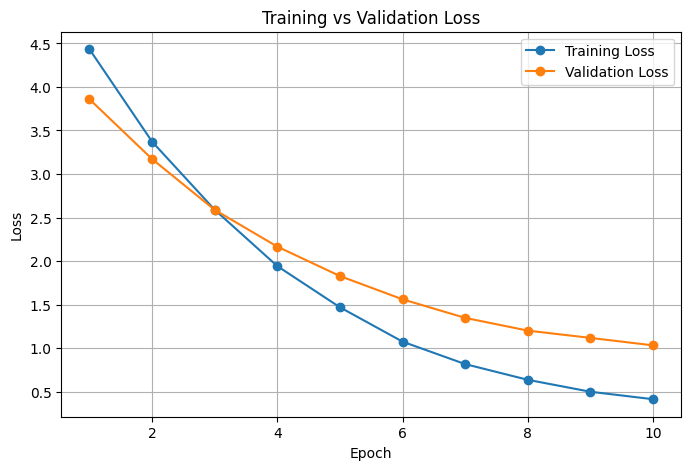

In [26]:
def plot_loss(train_losses, val_losses):

    plt.figure(figsize=(8,5))

    epochs = range(1, len(train_losses) + 1)  # As python lists are zero-indexed, so we convert it to 1-indexed for better understanding.

    plt.plot(epochs, train_losses, marker="o", label="Training Loss")
    plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()

plot_loss(train_losses, val_losses)

### Conclusion

The training loss decreases steadily throughout the training process, indicating that the model is successfully learning the training data. The validation loss also decreases across epochs, demonstrating that the model is able to generalize to unseen validation images.

The training loss remains lower than the validation loss, which is expected because the model is optimized on the training data. A small gap between the two curves appears in the later epochs, suggesting that the model is beginning to overfit slightly. However, since the validation loss continues to decrease rather than increase, the model still maintains good generalization performance.

Overall, the learning curves indicate that the feature extraction model has converged successfully and provides a strong baseline before applying fine-tuning.

## Training and Validation Accuracy

The training and validation accuracy are plotted across all epochs to evaluate the learning progress of the model. Comparing both curves helps determine how well the model generalizes to unseen validation data.

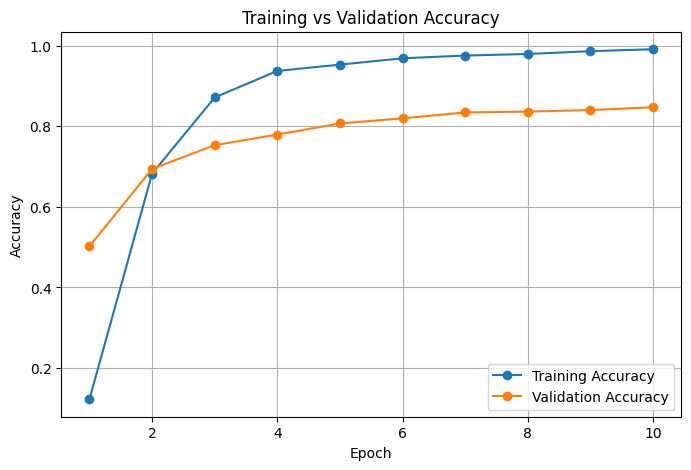

In [27]:
def plot_accuracy(train_accs, val_accs):

    plt.figure(figsize=(8,5))

    epochs = range(1, len(train_accs) + 1)

    plt.plot(epochs, train_accs, marker="o", label="Training Accuracy")
    plt.plot(epochs, val_accs, marker="o", label="Validation Accuracy")

    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()
    plt.grid(True)

    plt.show()

plot_accuracy(train_accs, val_accs)

### Conclusion

The training accuracy increases steadily throughout the training process, reaching approximately **98%**, indicating that the model has learned the training dataset effectively. The validation accuracy also improves consistently, reaching approximately **85%**, which demonstrates that the model generalizes well to unseen validation images.

A moderate gap between the training and validation accuracy appears during the later epochs. This suggests that the model is beginning to overfit the training data, although the validation accuracy continues to improve rather than decrease. Therefore, the model has not severely overfitted but still has scope for improvement through fine-tuning.

Overall, the accuracy curves show that the feature extraction approach successfully learned discriminative features and provides a strong baseline for further optimization.

### Visualizing Model Predictions
The trained model is used to predict the classes of unseen test images. The predicted labels are compared with the actual labels to visually evaluate the model's classification performance.

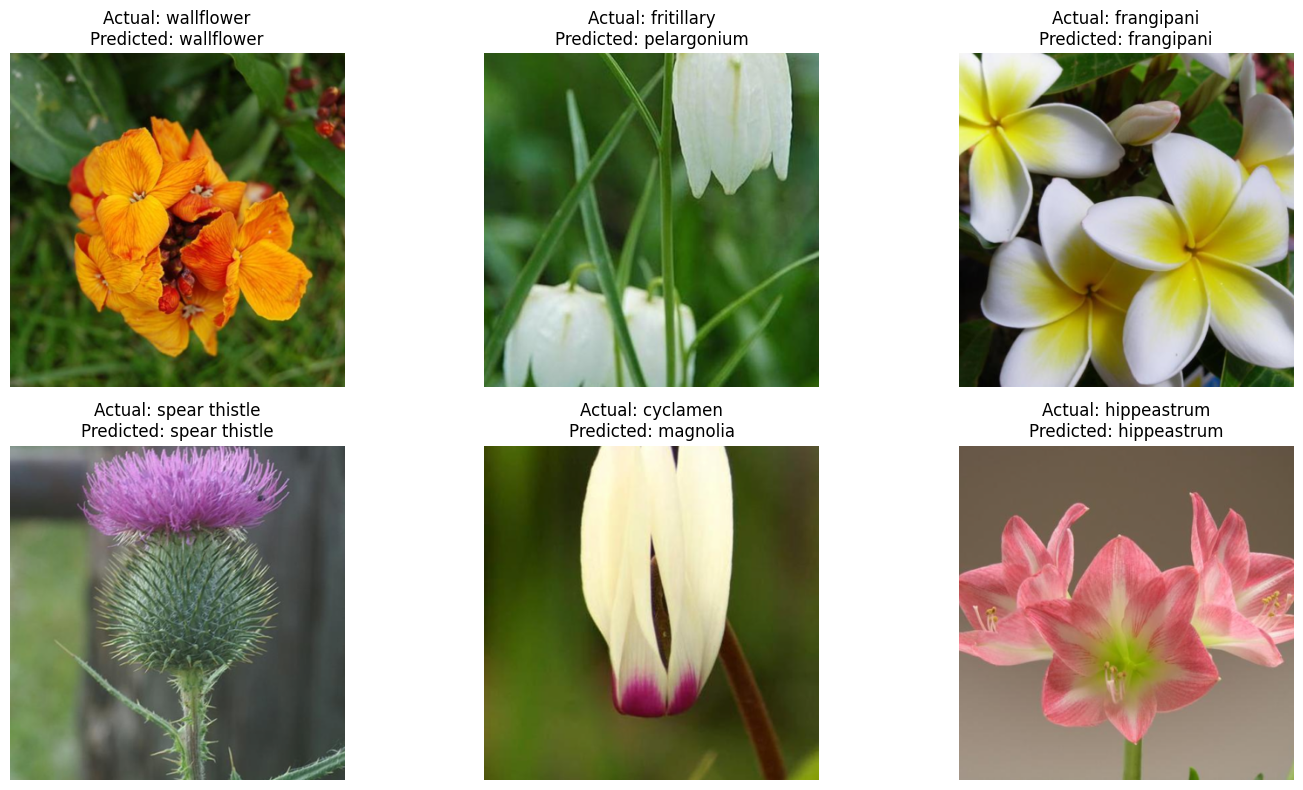

In [28]:
def visualize_predictions(model, test_dataset, device):

    # Putting model in the evaluation state:- this disables behaviour that are only used during training
    model.eval()

    # Randomly select 6 images from the test dataset
    indices = random.sample(range(len(test_dataset)), 6)

    images = []
    labels = []

    for idx in indices:
        image, label = test_dataset[idx]
        images.append(image)
        labels.append(label)

    images = torch.stack(images)
    labels = torch.tensor(labels)

    # Moving images to the GPU/CPU
    images = images.to(device)

    # Disabling gradient calculations
    with torch.no_grad():
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)    # This selects the highest score for each image

    # Moving tensor back to CPU:- Because NumPy and matplotlib works with CPU data
    images = images.cpu()
    predictions = predictions.cpu()
    labels = labels.cpu()

    # Displaying first 5 predictions
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    plt.figure(figsize=(15,8))

    for i in range(6):
        image = images[i].permute(1,2,0).numpy()

        # De-normalize
        image = image * std + mean
        image = np.clip(image,0,1)

        plt.subplot(2,3,i+1)
        plt.imshow(image)

        plt.title(
        f"Actual: {test_dataset.classes[labels[i].item()]}\n"
        f"Predicted: {test_dataset.classes[predictions[i].item()]}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_dataset, device)

### Observation

The prediction visualization demonstrates the model's performance on randomly selected test images. Out of the six displayed samples, few images were classified correctly, while sometimes few image was misclassified. The few incorrect prediction in some cases suggests that some flower species have similar visual characteristics, making them more challenging to distinguish.

Overall, the model correctly identifies most flower classes, which is consistent with the obtained **Test Accuracy of 82.26%**. This visualization provides qualitative evidence that the pretrained EfficientNetV2-S model has learned meaningful visual features for flower classification.

# Fine-Tuning the Pretrained Model

In feature extraction, only the __final classification layer__ was trained while the pretrained backbone remained frozen. During fine-tuning, selected layers of the backbone are unfrozen so that their weights can be updated. This allows the pretrained model to adapt its learned features to the Oxford Flowers102 dataset, often improving classification performance. Since pretrained weights already contain useful knowledge, a much smaller learning rate is used to prevent large updates that could destroy the learned features.

#### Now backbone and classifier both are trainable

In [29]:
# Freeze everything
for param in model.features.parameters():
    param.requires_grad = True

# Unfreeze only the last EfficientNet block
# for param in model.features[-2].parameters():
    # param.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)
transforms.Resize((224, 224))

Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)

## Training the Fine-Tuned Model

After unfreezing the backbone layers, the model is trained again using a small learning rate. Unlike feature extraction, where only the classifier was updated, fine-tuning allows both the pretrained backbone and the classifier to learn from the Oxford Flowers102 dataset. This helps the model adapt its learned features to the new task while preserving the useful knowledge acquired during pretraining.



In [30]:
# We will use the feature - extraction fit method because that is same for fine-tumed model, no need for changes for that one in this
fine_tune_epochs=20
ft_train_losses, ft_train_accs, ft_val_losses, ft_val_accs=fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=fine_tune_epochs
)

Epoch [1/20]Train Loss: 0.2519 | Train Accuracy: 0.9951 | Validation Loss: 0.7736 | Validation Accuracy: 0.8667  
Epoch [2/20]Train Loss: 0.1678 | Train Accuracy: 0.9951 | Validation Loss: 0.6836 | Validation Accuracy: 0.8745  
Epoch [3/20]Train Loss: 0.1255 | Train Accuracy: 0.9990 | Validation Loss: 0.6480 | Validation Accuracy: 0.8775  
Epoch [4/20]Train Loss: 0.1006 | Train Accuracy: 0.9961 | Validation Loss: 0.6143 | Validation Accuracy: 0.8814  
Epoch [5/20]Train Loss: 0.0788 | Train Accuracy: 1.0000 | Validation Loss: 0.5701 | Validation Accuracy: 0.8882  
Epoch [6/20]Train Loss: 0.0681 | Train Accuracy: 0.9990 | Validation Loss: 0.5435 | Validation Accuracy: 0.8912  
Epoch [7/20]Train Loss: 0.0600 | Train Accuracy: 0.9990 | Validation Loss: 0.5231 | Validation Accuracy: 0.8931  
Epoch [8/20]Train Loss: 0.0486 | Train Accuracy: 1.0000 | Validation Loss: 0.5072 | Validation Accuracy: 0.8951  
Epoch [9/20]Train Loss: 0.0447 | Train Accuracy: 0.9990 | Validation Loss: 0.4879 | Vali

Feature extraction uses more epochs because the newly added classifier starts with randomly initialized weights and must learn from scratch. Fine-tuning uses fewer epochs because the model already contains pretrained knowledge, and only small adjustments are needed to adapt it to the target dataset while reducing the risk of overfitting.

### Fine-Tuning Results

Fine-tuning achieved higher validation accuracy because the final EfficientNetV2 blocks were allowed to update their pretrained representations according to flower-specific patterns. Unlike feature extraction, where only the classifier learns, fine-tuning adapts high-level visual features, resulting in improved generalization on the Flowers102 dataset.

### Evaluating Fine-Tuned model on Test Dataset

In [31]:
model.load_state_dict(torch.load("best_model.pth", weights_only=True))

ft_test_loss, ft_test_acc = evaluate(
    model,
    test_loader,
    loss_function,
    device
)

print(f"Fine-Tuned Test Loss: {ft_test_loss:.4f}")
print(f"Fine-Tuned Test Accuracy: {ft_test_acc:.4f}")

Fine-Tuned Test Loss: 0.4388
Fine-Tuned Test Accuracy: 0.8998


### Fine-Tuning Test Results

The fine-tuned model achieved a **Test Accuracy of 89.98%**, compared to **82.97%** obtained using feature extraction. The **Test Loss** also decreased from **1.0761** to **0.4388**, shows that the model made more confident and accurate predictions after fine-tuning.

Although the improvement is very lesses but it demonstrates that allowing the pretrained backbone to adapt to the Oxford Flowers102 dataset helped improve the model's generalization performance.

### Training and validation loss

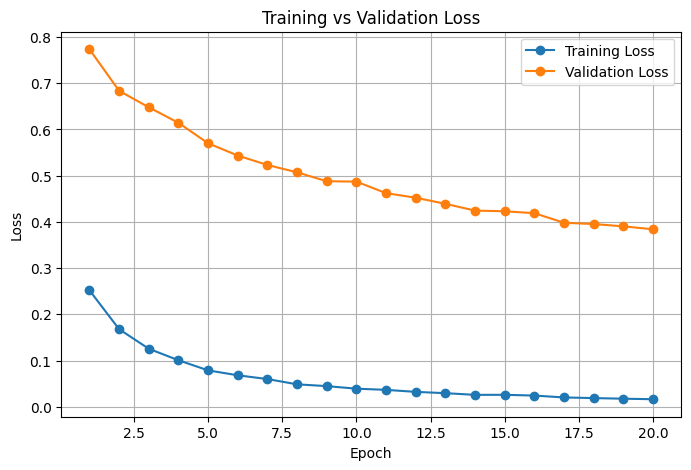

In [32]:
plot_loss(ft_train_losses, ft_val_losses)

### Fine-Tuning Loss Curve Analysis

The training loss remained low throughout fine-tuning, while the validation loss gradually decreased from 1.14 to 0.97. This indicates that the model continued to improve its predictions on unseen validation images. Since the validation loss did not increase, there is no strong evidence of severe overfitting during fine-tuning.


### Training and validation accuracy

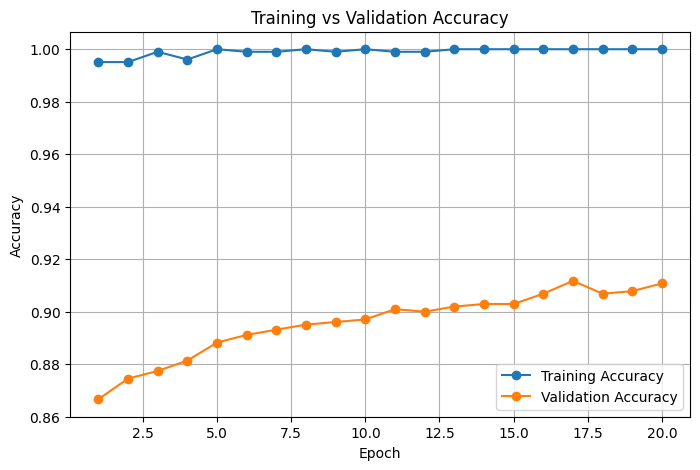

In [33]:
plot_accuracy(ft_train_accs, ft_val_accs)

Feature extraction showed a rapid increase in training accuracy because only the newly added classifier layer was trained while the pretrained EfficientNetV2-S backbone remained frozen. Initially, the classifier had random weights but quickly learned to map extracted ImageNet features to flower categories.

Fine-tuning produced a different learning curve because the model started with strong pretrained representations and only adapted the final EfficientNet blocks. This resulted in high initial accuracy and gradual improvement in validation accuracy. Fine-tuning achieved better performance because the high-level features were adapted specifically for Flowers102 flower characteristics.

### Visualizing the images and labels with fine tuned model

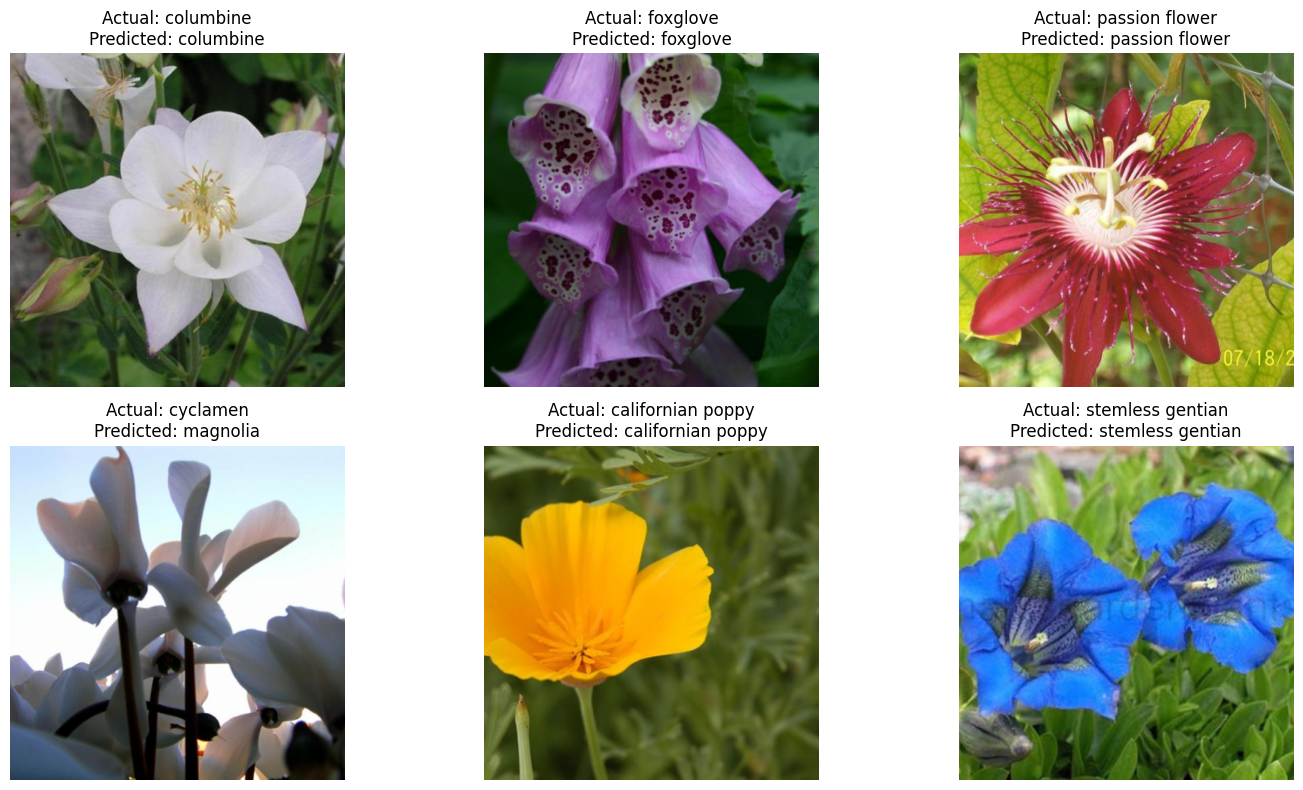

In [34]:
visualize_predictions(model, test_dataset, device)

## Comparison of Feature Extraction and Fine-tuning Results

Two transfer learning strategies were evaluated using the EfficientNetV2-S pretrained model on the Oxford Flowers102 dataset.

### Experiment 1: Feature Extraction
- The EfficientNetV2-S backbone was kept frozen.
- Only the final classifier layer was trained.
- The pretrained ImageNet features were directly used for flower classification.

### Experiment 2: Fine-tuning
- The last two feature blocks of EfficientNetV2-S were unfrozen.
- Both the classifier and selected backbone layers were trained.
- The model was allowed to adapt high-level features to Flowers102-specific patterns.

### Performance Comparison

| Experiment | Strategy | Test Accuracy |
|------------|----------|---------------|
| Experiment 1 | Feature Extraction (Frozen Backbone + Trained Classifier) | 82.97% |
| Experiment 2 | Fine-tuning (Unfrozen Backbone + Trained Backbone with Classifier | 89.98% |

### Observation

Fine-tuning achieved better performance compared to feature extraction.

The improvement occurred because fine-tuning allowed the pretrained EfficientNetV2-S feature representations to adapt to the specific characteristics of the Flowers102 dataset, such as flower textures, colors, and fine-grained visual differences.

Feature extraction still provided strong performance because the ImageNet-pretrained backbone already learned useful visual representations.

## Test Set Prediction

The fine-tuned EfficientNetV2-S model is evaluated on the Flowers102 test set.  
The `get_predictions()` function performs inference on test images and stores the actual labels and predicted labels, which are later used to generate the classification report and confusion matrix.

In [35]:
def get_predictions(model, dataloader):

    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            # print("Batch:", batch_idx)
            images = images.to(device)
            outputs = model(images)
            predictions = torch.argmax(
                outputs,
                dim=1
            )
            y_pred.extend(
                predictions.cpu().numpy()
            )

            y_true.extend(
                labels.numpy()
            )

    return y_true, y_pred

In [36]:
model.eval()
y_true, y_pred = get_predictions(
    model,
    test_loader
)

In [37]:
print(len(y_true))
print(len(y_pred))

6149
6149


## Classification Report

The classification report evaluates the performance of the fine-tuned EfficientNetV2-S model on the Flowers102 test dataset using precision, recall, and F1-score for each flower category.

In [38]:
from sklearn.metrics import classification_report
report = classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes
)
print(report)

                           precision    recall  f1-score   support

            pink primrose       0.63      0.95      0.76        20
hard-leaved pocket orchid       0.95      0.97      0.96        40
         canterbury bells       0.50      0.70      0.58        20
                sweet pea       0.75      0.67      0.71        36
         english marigold       0.89      0.91      0.90        45
               tiger lily       1.00      1.00      1.00        25
              moon orchid       0.59      1.00      0.74        20
         bird of paradise       0.96      1.00      0.98        65
                monkshood       0.89      0.92      0.91        26
            globe thistle       0.96      1.00      0.98        25
               snapdragon       0.89      0.70      0.78        67
              colt's foot       0.97      0.94      0.95        67
              king protea       0.97      1.00      0.98        29
            spear thistle       0.90      0.96      0.93     

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy:", accuracy)
print("Percentage:", accuracy*100)

Accuracy: 0.8998211091234347
Percentage: 89.98211091234347


## Confusion Matrix

The confusion matrix visualizes the classification performance of the fine-tuned EfficientNetV2-S model across all 102 flower categories. It shows the correctly classified samples along the diagonal and misclassified samples between different classes.

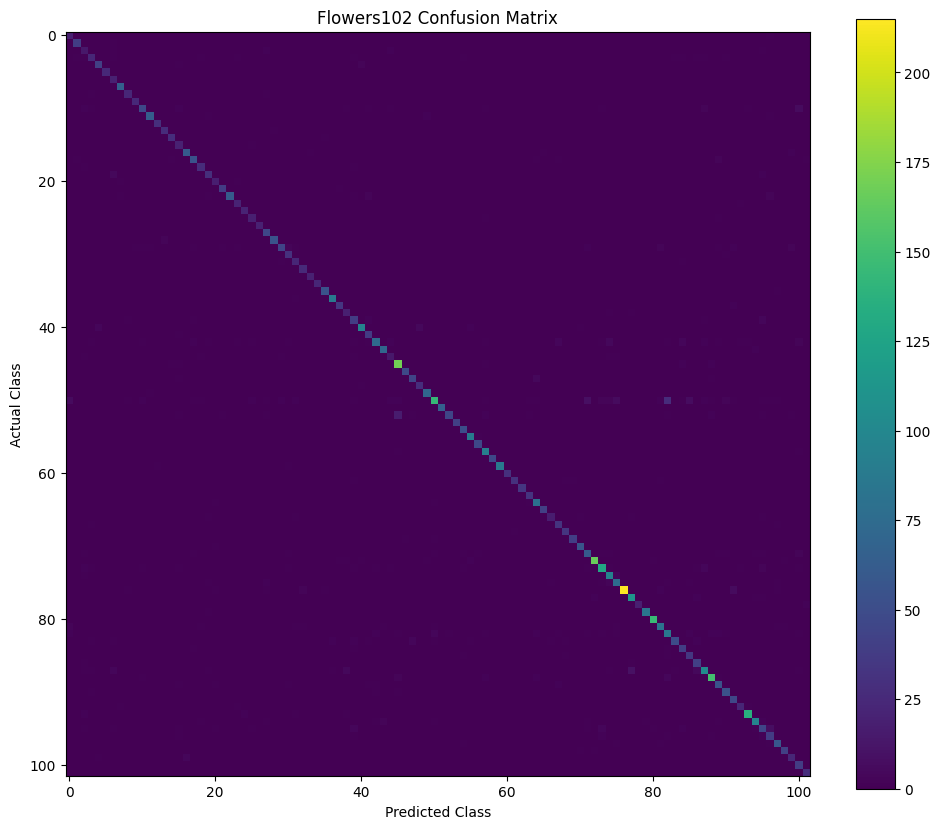

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12,10))

plt.imshow(cm)

plt.colorbar()

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title("Flowers102 Confusion Matrix")

plt.show()

In [41]:
import numpy as np

cm_copy = cm.copy()

# Removeing correct predictions (diagonal values)
np.fill_diagonal(cm_copy, 0)

# Finding the top 10 highest confusion pairs
for index in np.argsort(cm_copy.ravel())[-10:][::-1]:    # ravel is use for flattening the matrix and argsort-> sorts the index with -10 as from back
    actual, predicted = np.unravel_index(   # Converting 1D index back to row and column
        index,
        cm.shape
    )

    print(
        train_dataset.classes[actual],
        "→",
        train_dataset.classes[predicted],
        "Count:",
        cm[actual][predicted]    # It tells how many times it were predicted wrong
    )

petunia → hibiscus Count: 27
primula → wallflower Count: 16
cyclamen → lotus Count: 10
petunia → azalea Count: 9
camellia → mallow Count: 8
petunia → tree mallow Count: 7
passion flower → bee balm Count: 6
snapdragon → trumpet creeper Count: 6
petunia → pink primrose Count: 6
petunia → morning glory Count: 6


**Observation:** The model most frequently confused **Primula** with **Wallflower** (19 instances). **Petunia** appeared in multiple confused pairs, suggesting it was one of the most challenging flower classes to distinguish. These confusions are likely due to similarities in flower shape, color, petal structure, and other fine-grained visual characteristics.

### Saving the best model

In [42]:
torch.save(
    model.state_dict(),
    "efficientnetv2_s_flowers102_finetuned.pth"
)